# Stock Price Time Series Forecasting

## Objective
Analyze historical stock prices and forecast future prices using machine learning.

In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Load Dataset
df = pd.read_csv("../data/stock_prices.csv")

df.head()

,Date,Price
0,2024-01-01,100
1,2024-01-02,102
2,2024-01-03,101
3,2024-01-04,105
4,2024-01-05,107


In [5]:
# Convert Dates
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    15 non-null     datetime64[us]
 1   Price   15 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 372.0 bytes


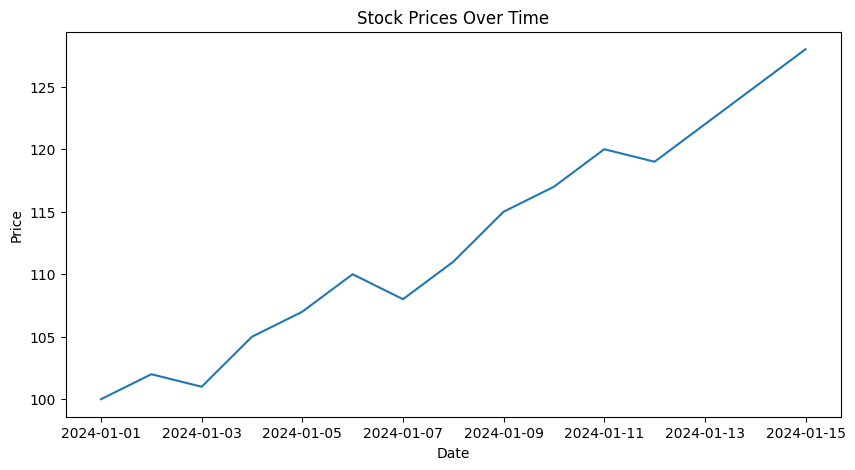

In [6]:
# Visualize Stock Prices
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Price'])

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [9]:
# Prepare Data for Forecasting
df['Day'] = range(1, len(df) + 1)

X = df[['Day']]
y = df['Price']

In [8]:
# Train Forecasting Model
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Predict Existing Prices
predictions = model.predict(X)

predictions

array([ 98.79166667, 100.77380952, 102.75595238, 104.73809524,
       106.7202381 , 108.70238095, 110.68452381, 112.66666667,
       114.64880952, 116.63095238, 118.61309524, 120.5952381 ,
       122.57738095, 124.55952381, 126.54166667])

In [13]:
# Forecast Future Prices
future_days = pd.DataFrame({
    'Day': [16, 17, 18, 19, 20]
})

future_predictions = model.predict(future_days)

future_predictions

array([128.52380952, 130.50595238, 132.48809524, 134.4702381 ,
       136.45238095])

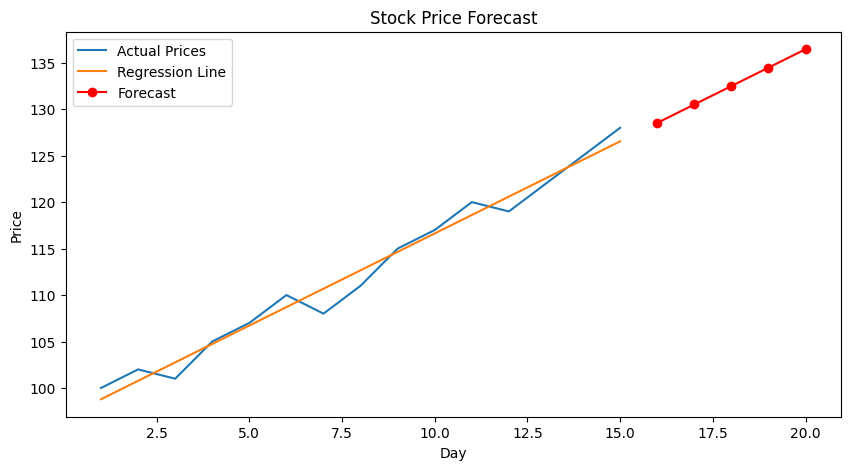

In [12]:
# Visualize Forecast

plt.figure(figsize=(10,5))

### Original data
plt.plot(df['Day'], y, label="Actual Prices")

### Predicted line
plt.plot(df['Day'], predictions, label="Regression Line")

### Future predictions
future_x = [16,17,18,19,20]

plt.plot(future_x, future_predictions, 'ro-', label="Forecast")

plt.xlabel("Day")
plt.ylabel("Price")

plt.title("Stock Price Forecast")

plt.legend()

plt.show()

# Key Insights

- Stock prices show an upward trend over time.
- Linear regression successfully identifies the trend.
- Forecasting predicts continued growth in future stock prices.